# 02 — Model analysis

This notebook compares Custom CNN, EfficientNetB0, and MobileNetV2 using saved training and evaluation artifacts. Results are measured only when matching artifacts exist. It never substitutes fabricated metrics. EfficientNetB0 remains the predetermined application model.

This application is an academic/research prototype for brain MRI image classification. It is not a medical diagnostic device and should not be used to make medical decisions. Predictions should be reviewed by qualified medical professionals.

In [1]:
from pathlib import Path
import sys

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((path for path in candidates if (path / "config" / "config.yaml").is_file() and (path / "src").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import load_config, resolve_path
from models.registry import MODEL_NAMES, DISPLAY_NAMES
config = load_config(PROJECT_ROOT / "config" / "config.yaml")
print(f"Project: {PROJECT_ROOT.name}; task: {config['task']}")

Project: Brain_tumorˍDetection; task: binary


## Experiment comparison

Every available model pair must have matching dataset fingerprints, task, class order, threshold, and test sample counts. The table always includes all three registered models. Missing experiments remain `Not available`; incompatible results raise an actionable error.

In [2]:
from src.compare import compare_experiments
comparison = compare_experiments(config)
display(comparison)

,Model,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC
0,Custom CNN,0.871951,0.934378,0.886617,0.909871,0.8325,0.933195
1,EfficientNetB0,0.933604,0.995943,0.912639,0.952473,0.9900,0.984977
2,MobileNetV2,0.928862,0.988922,0.912639,0.949251,0.9725,0.982012


## Measured evaluation artifacts


Custom CNN


,precision,recall,sensitivity,specificity,f1,roc_auc,support,tp,tn,fp,fn
no_tumor,0.731868,0.832500,0.832500,0.886617,0.778947,0.933195,400,333,954,122,67
tumor,0.934378,0.886617,0.886617,0.832500,0.909871,0.933195,1076,954,333,67,122


Dataset fingerprint: 7cbfdfaf4cb792140f3144366a6f56b31d0d1ecd8a866e6d4749dd874927715a
Test images: 1476 | threshold: 0.5


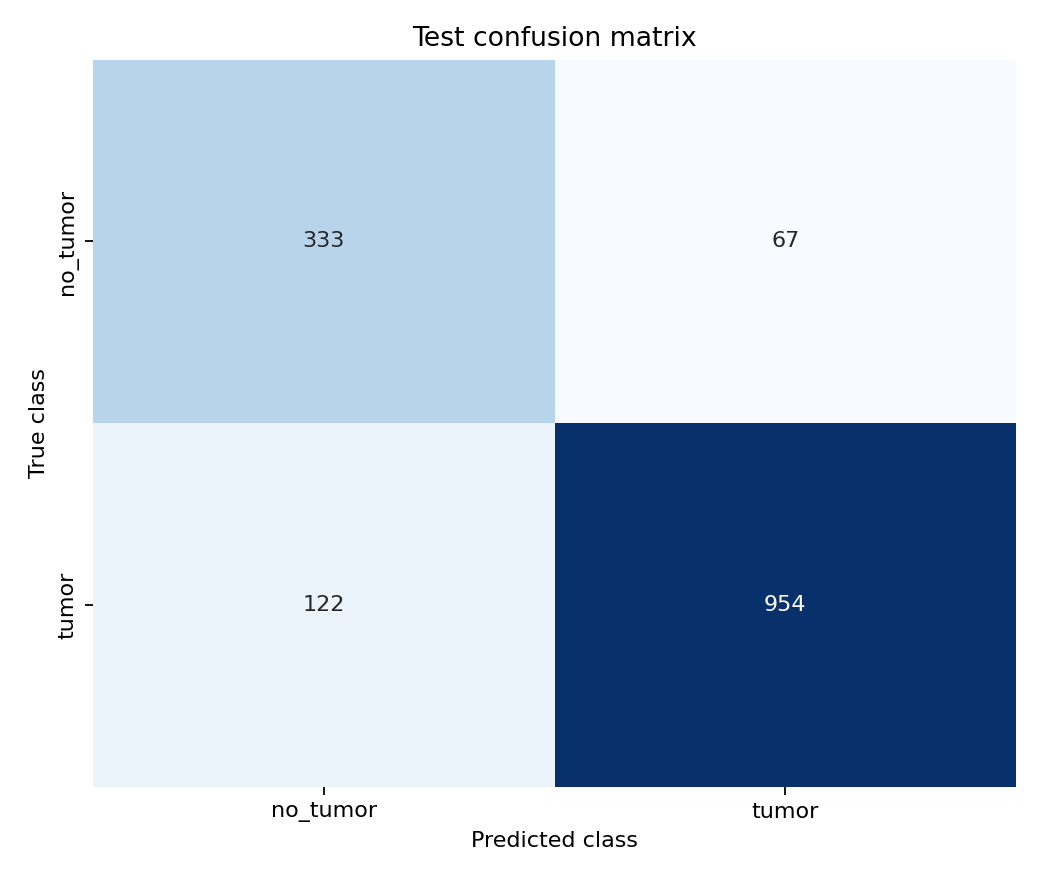

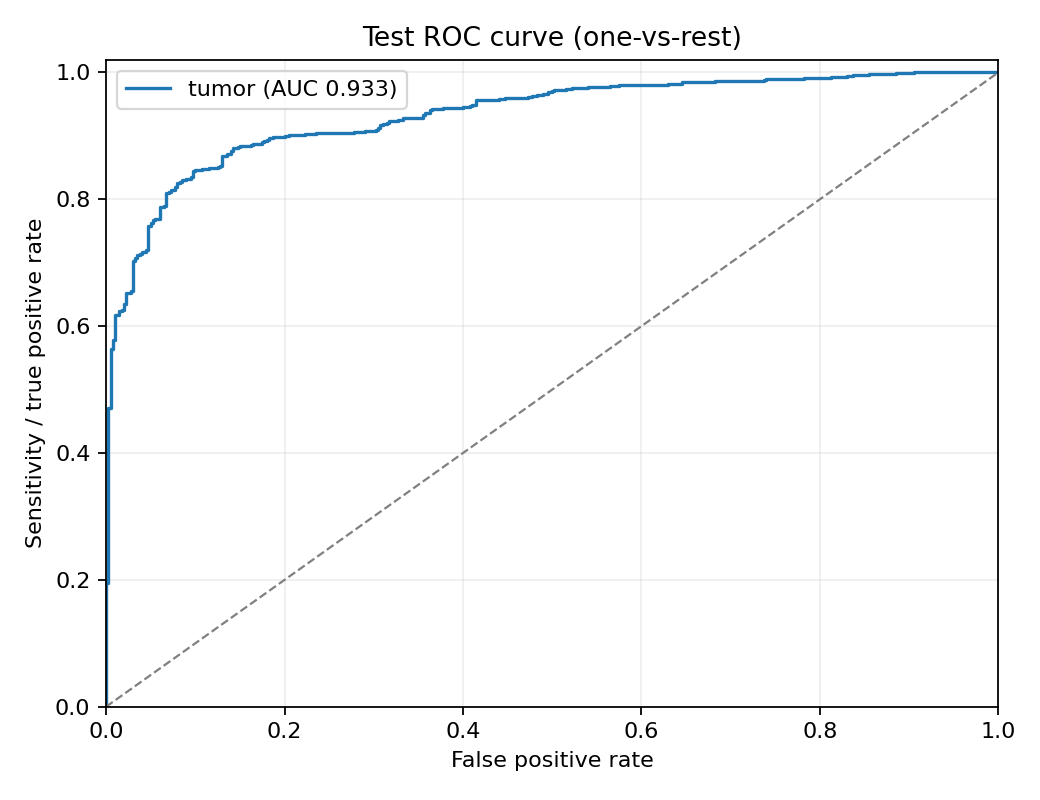

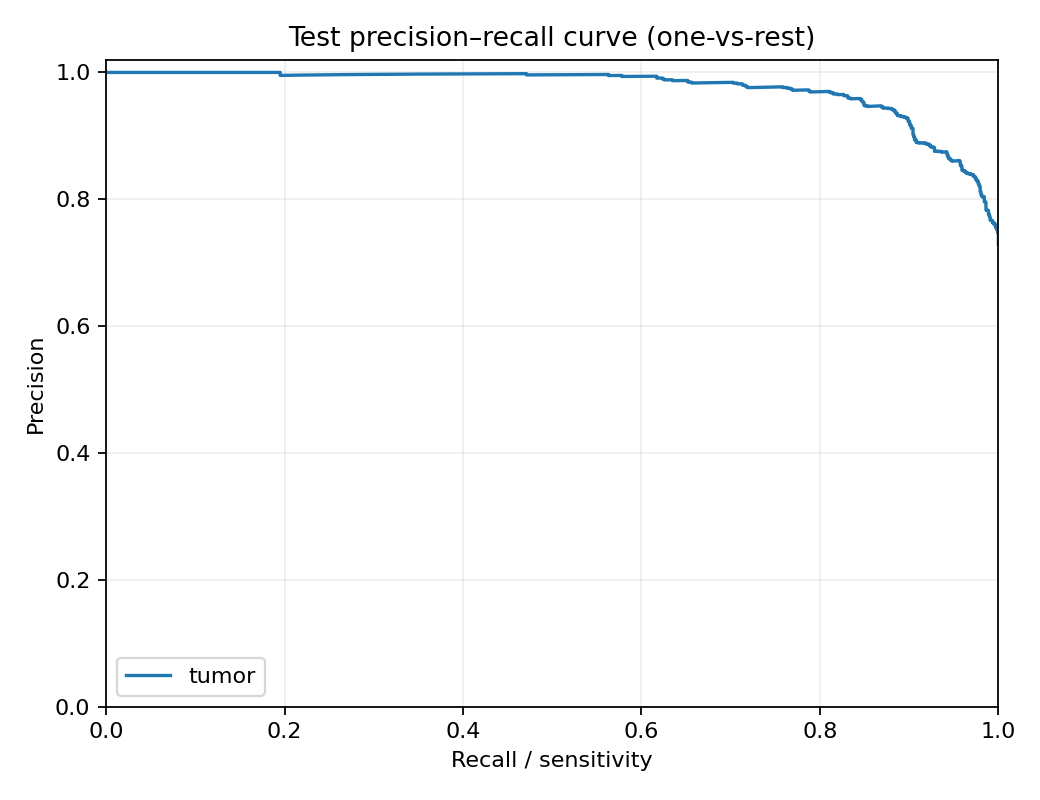


EfficientNetB0


,precision,recall,sensitivity,specificity,f1,roc_auc,support,tp,tn,fp,fn
no_tumor,0.808163,0.990000,0.990000,0.912639,0.889888,0.984977,400,396,982,94,4
tumor,0.995943,0.912639,0.912639,0.990000,0.952473,0.984977,1076,982,396,4,94


Dataset fingerprint: 7cbfdfaf4cb792140f3144366a6f56b31d0d1ecd8a866e6d4749dd874927715a
Test images: 1476 | threshold: 0.5


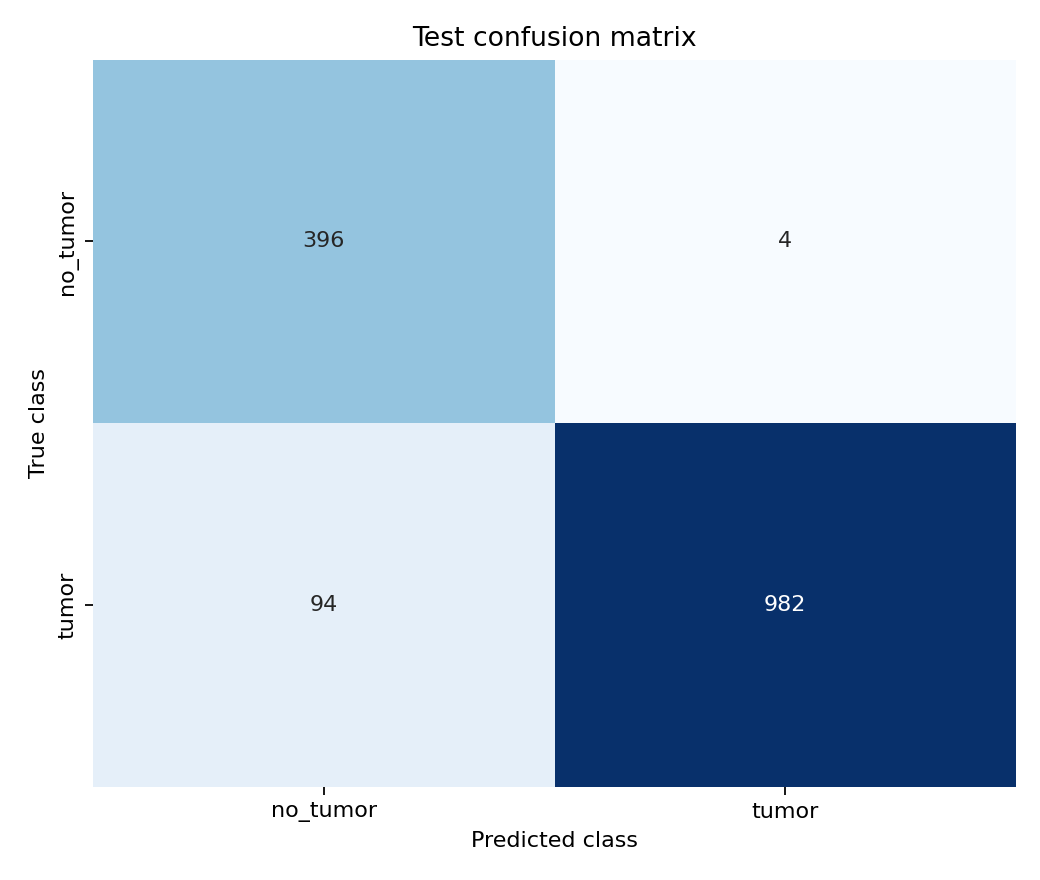

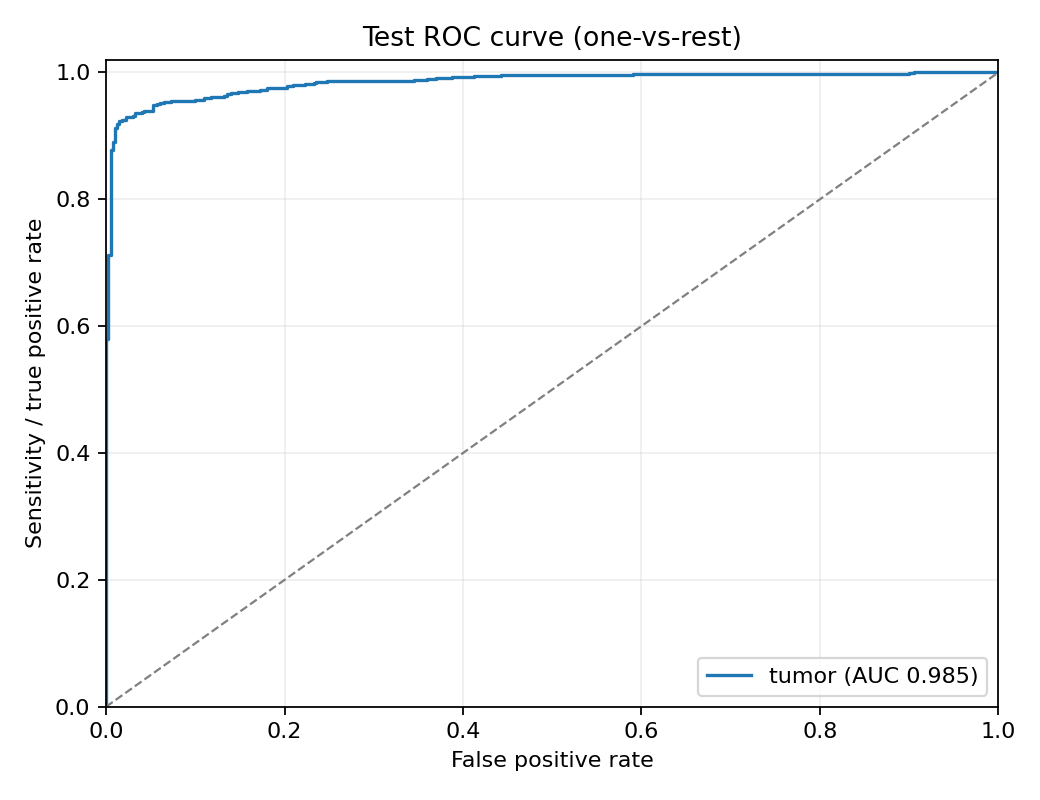

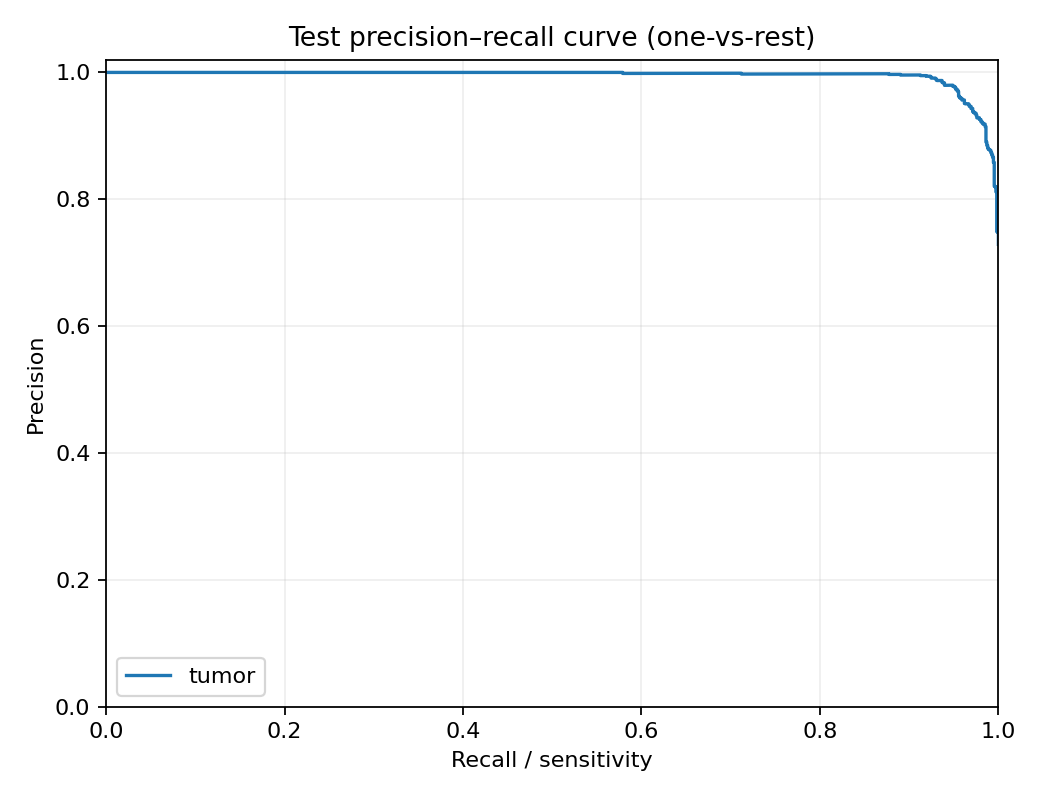


MobileNetV2


,precision,recall,sensitivity,specificity,f1,roc_auc,support,tp,tn,fp,fn
no_tumor,0.805383,0.972500,0.972500,0.912639,0.881087,0.982012,400,389,982,94,11
tumor,0.988922,0.912639,0.912639,0.972500,0.949251,0.982012,1076,982,389,11,94


Dataset fingerprint: 7cbfdfaf4cb792140f3144366a6f56b31d0d1ecd8a866e6d4749dd874927715a
Test images: 1476 | threshold: 0.5


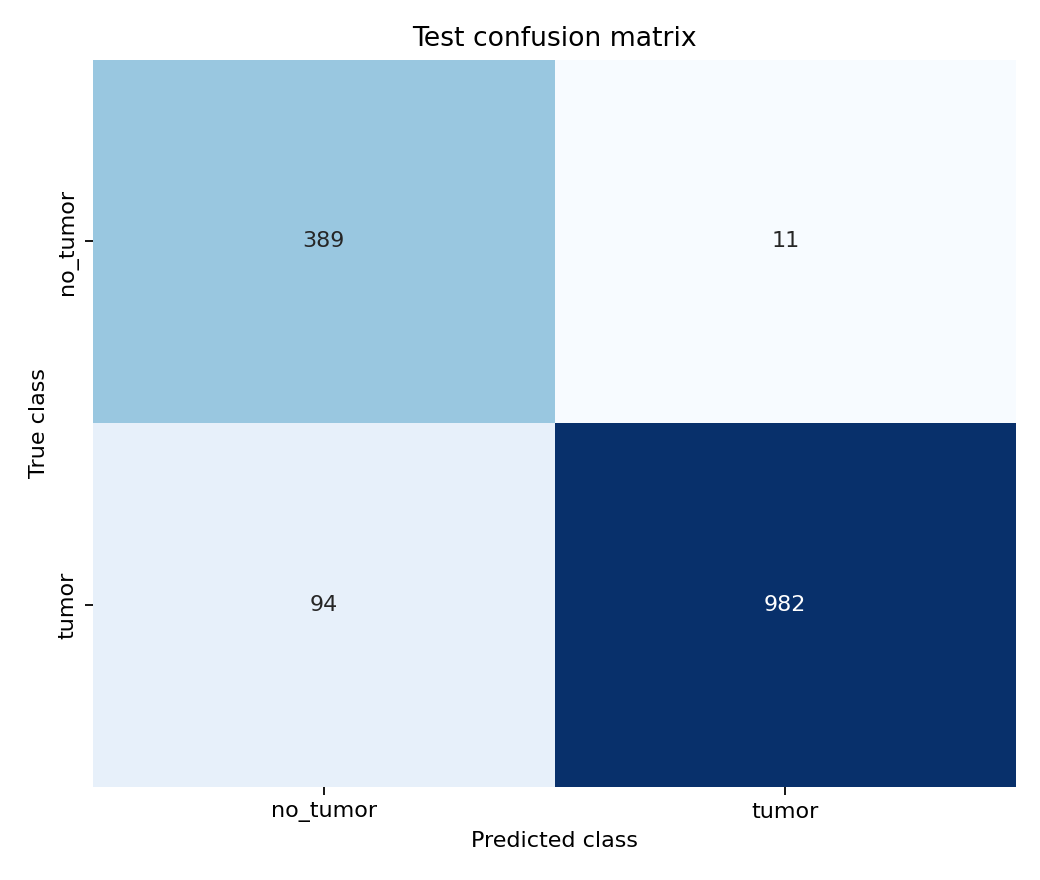

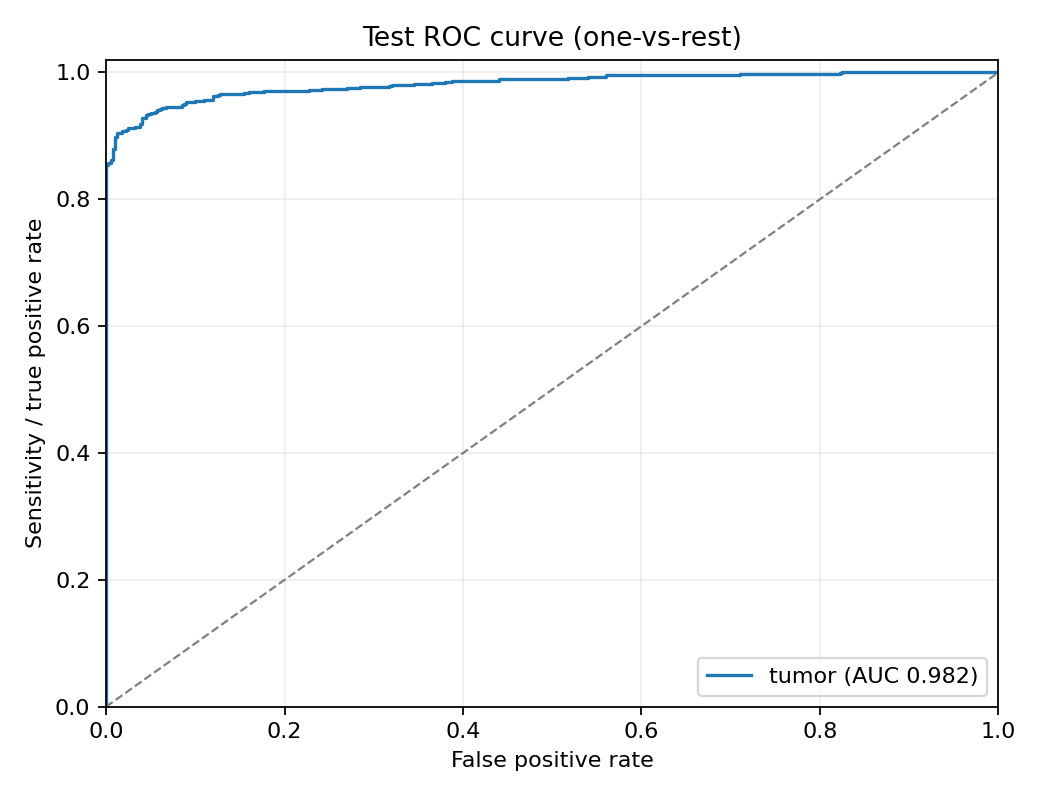

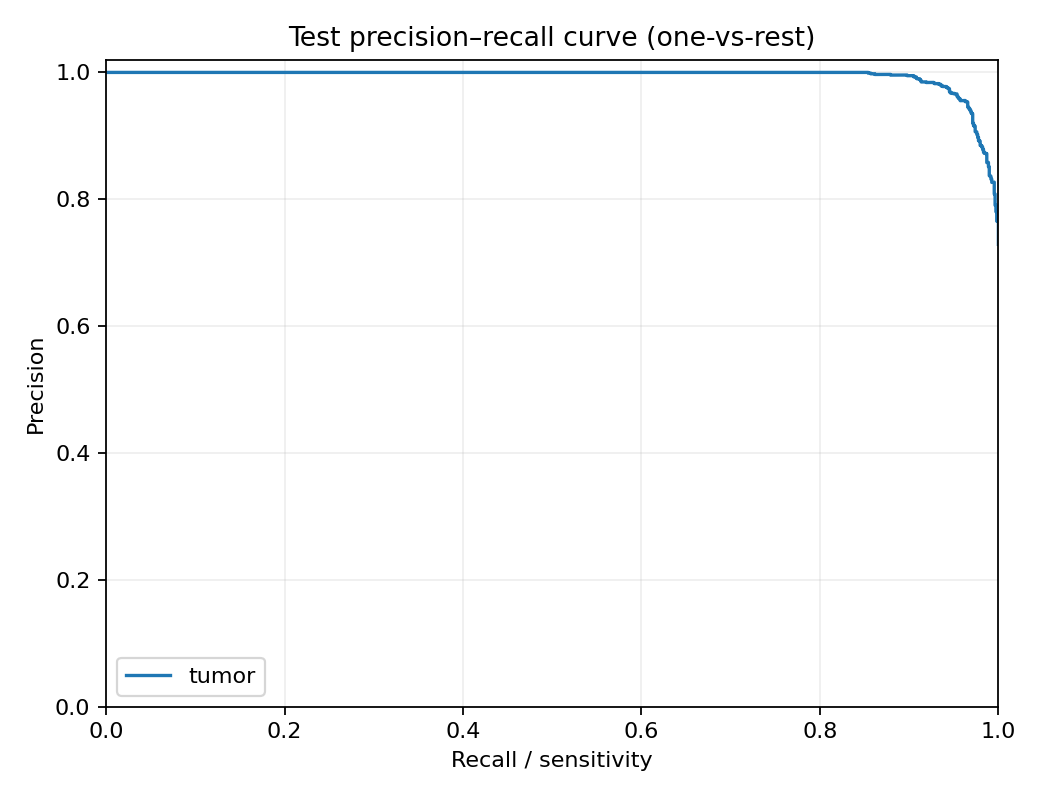

In [3]:
import json
import pandas as pd
from IPython.display import Image, display

evaluation_root = resolve_path(config["evaluation_dir"], config)
records = {}
for model_name in MODEL_NAMES:
    directory = evaluation_root / model_name
    metrics_path = directory / "metrics.json"
    print(f"\n{DISPLAY_NAMES[model_name]}")
    if not metrics_path.is_file():
        print("Not available. Training required — no measured result available.")
        continue
    record = json.loads(metrics_path.read_text(encoding="utf-8"))
    records[model_name] = record
    display(pd.DataFrame.from_dict(record["per_class"], orient="index"))
    print("Dataset fingerprint:", record["dataset_fingerprint"])
    print("Test images:", record["n_samples"], "| threshold:", record["threshold"])
    for filename in ("confusion_matrix.png", "roc_curve.png", "precision_recall_curve.png"):
        path = directory / filename
        if path.is_file():
            display(Image(filename=str(path), width=650))

## Training curves and overfitting

Inspect both loss and accuracy. A growing training/validation gap can suggest overfitting. Use validation data to select training changes and leave the test population for final evaluation. A curve alone cannot establish why a model generalizes poorly.

Custom CNN
accuracy.png


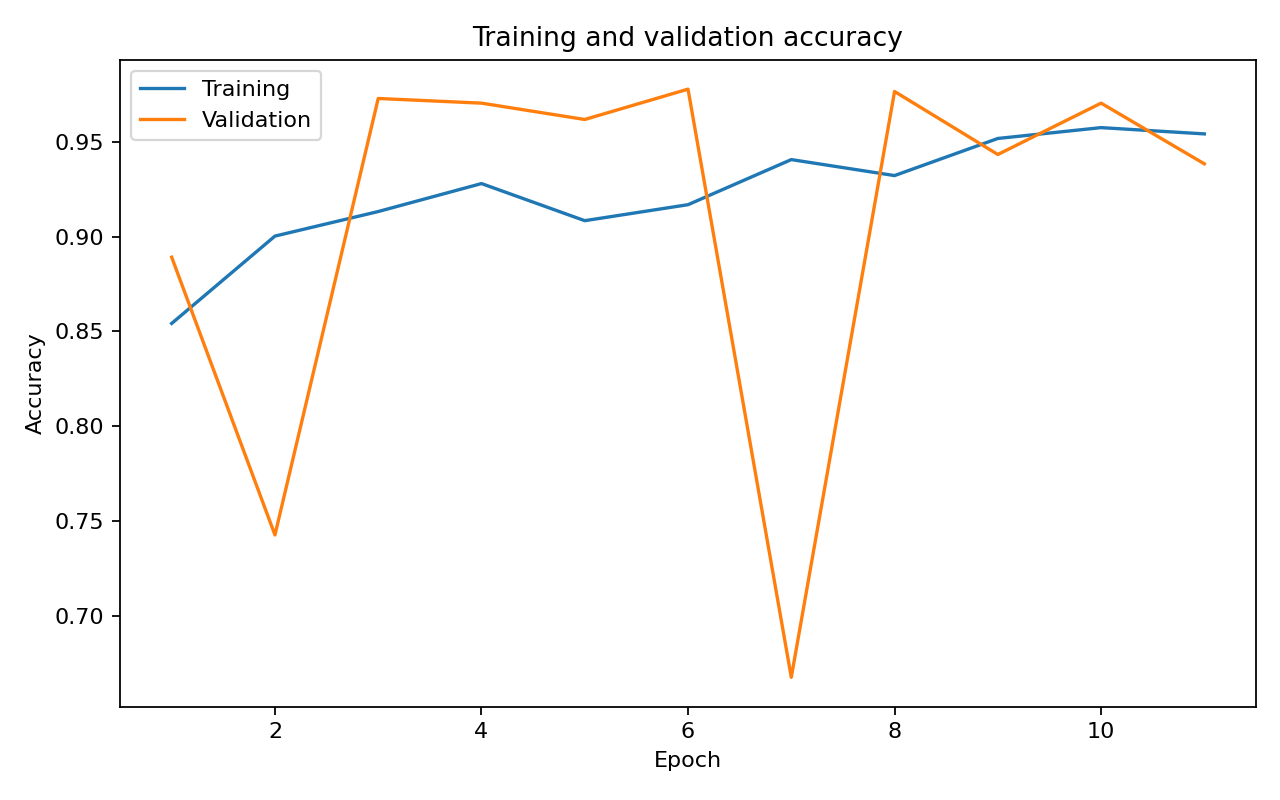

loss.png


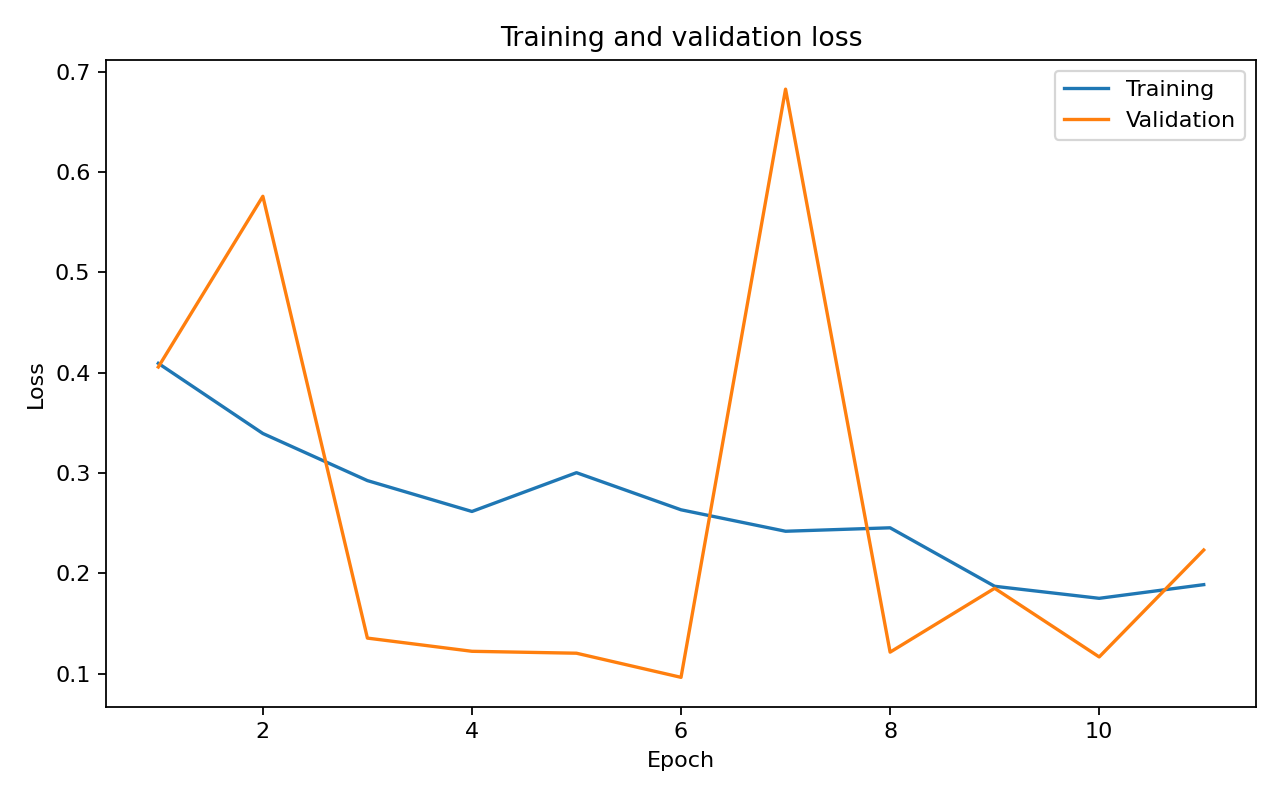

EfficientNetB0
accuracy.png


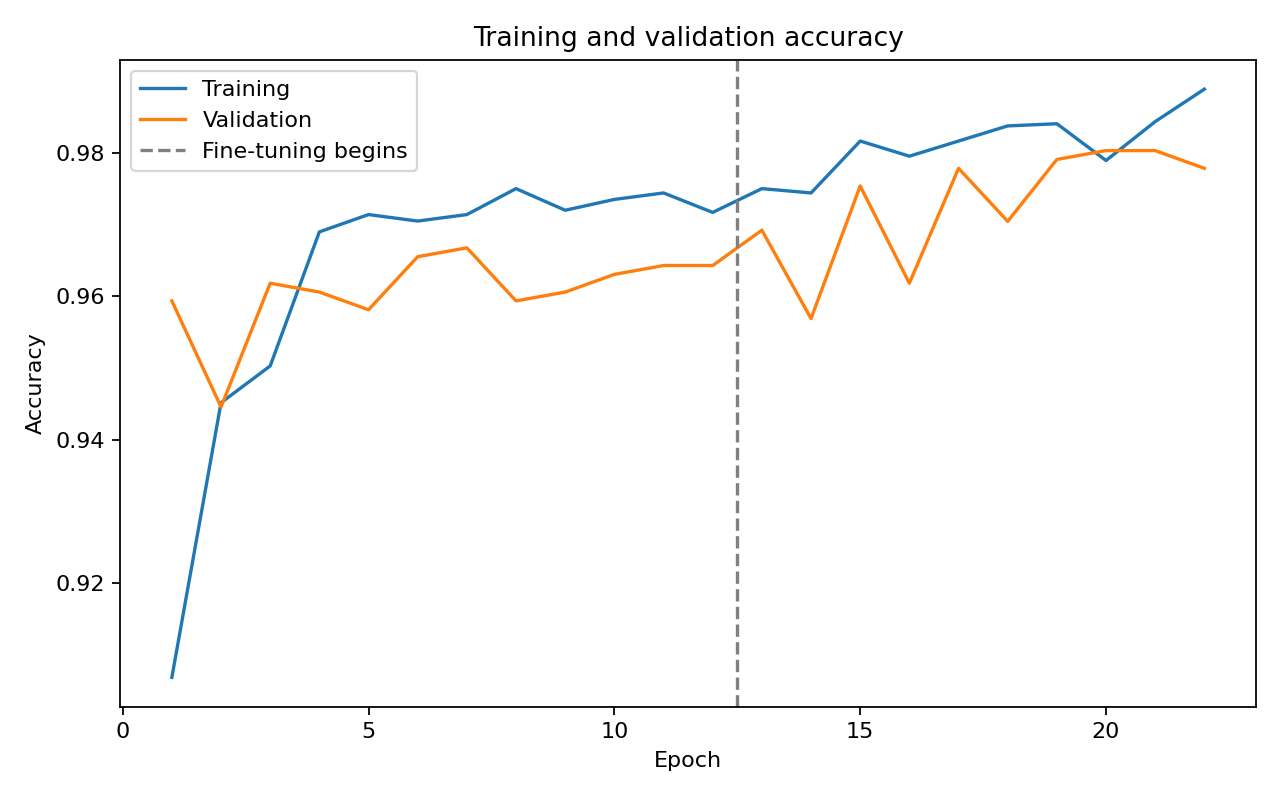

loss.png


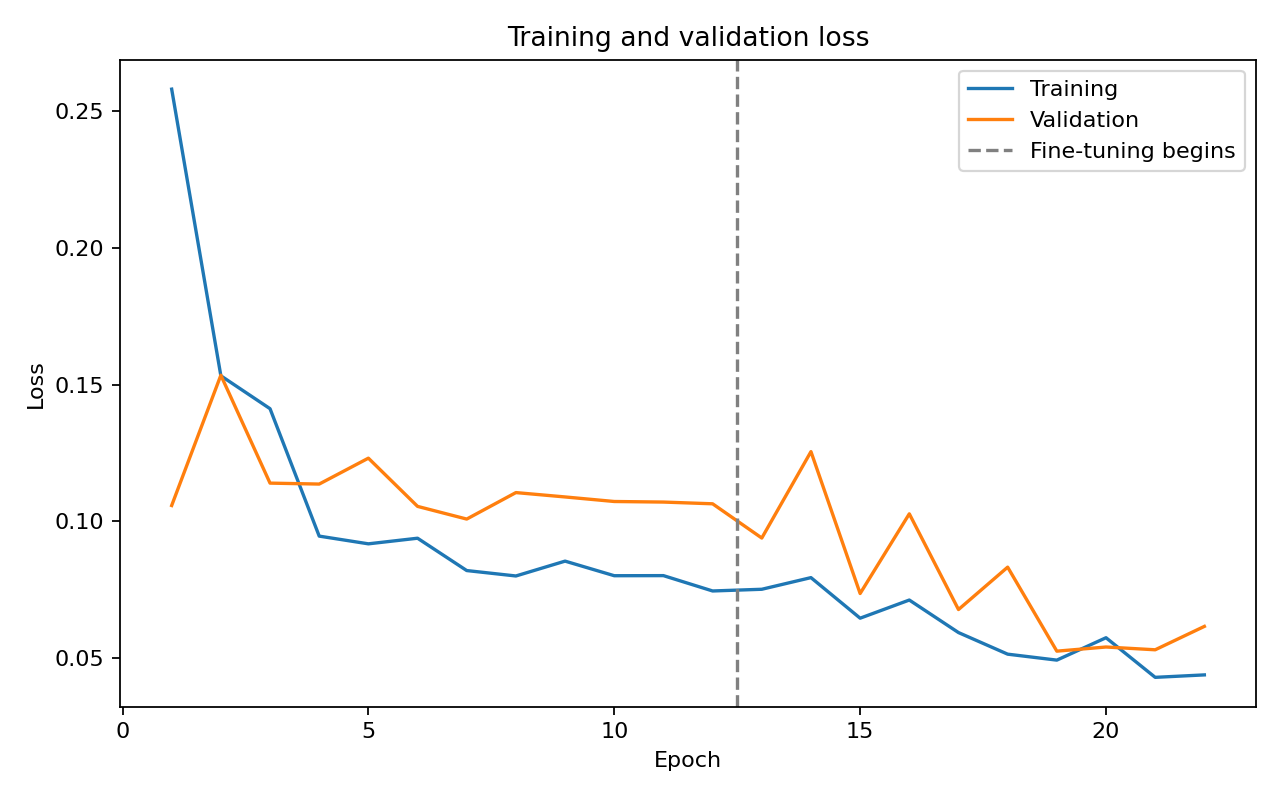

MobileNetV2
accuracy.png


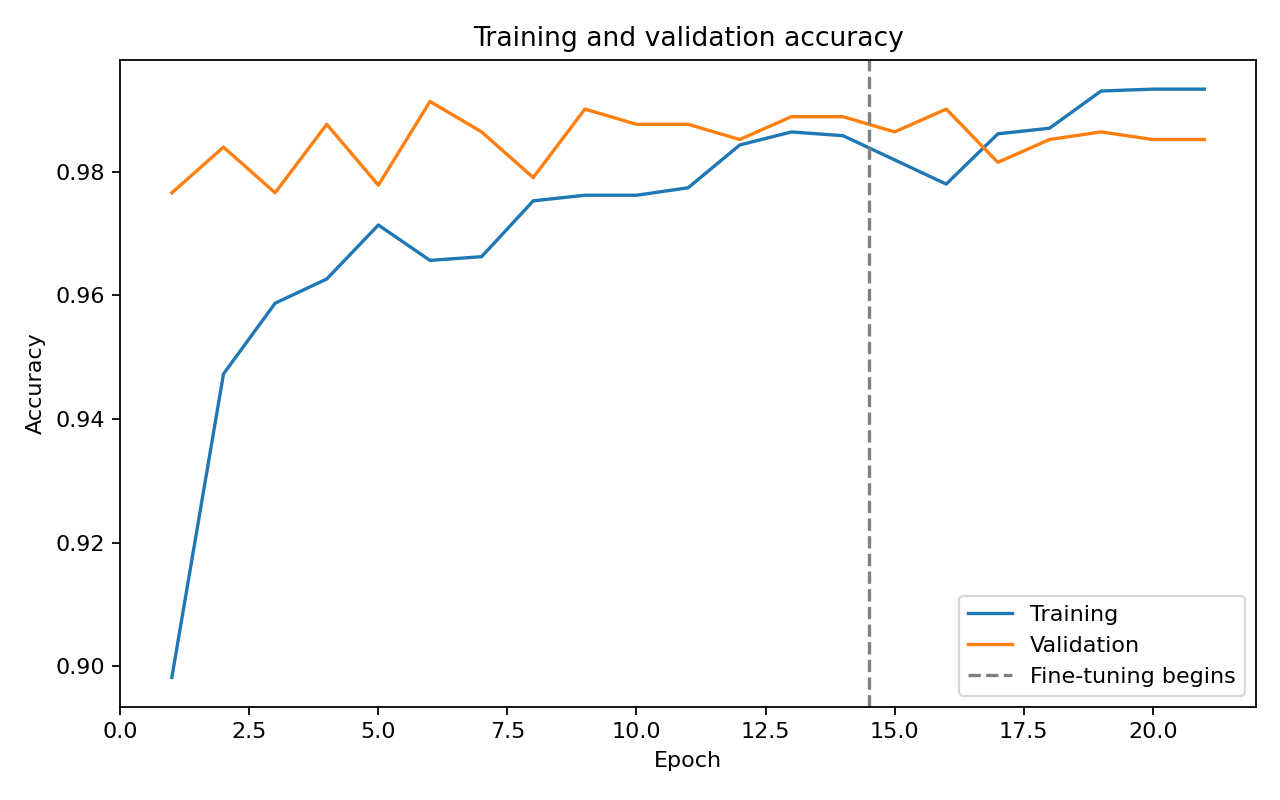

loss.png


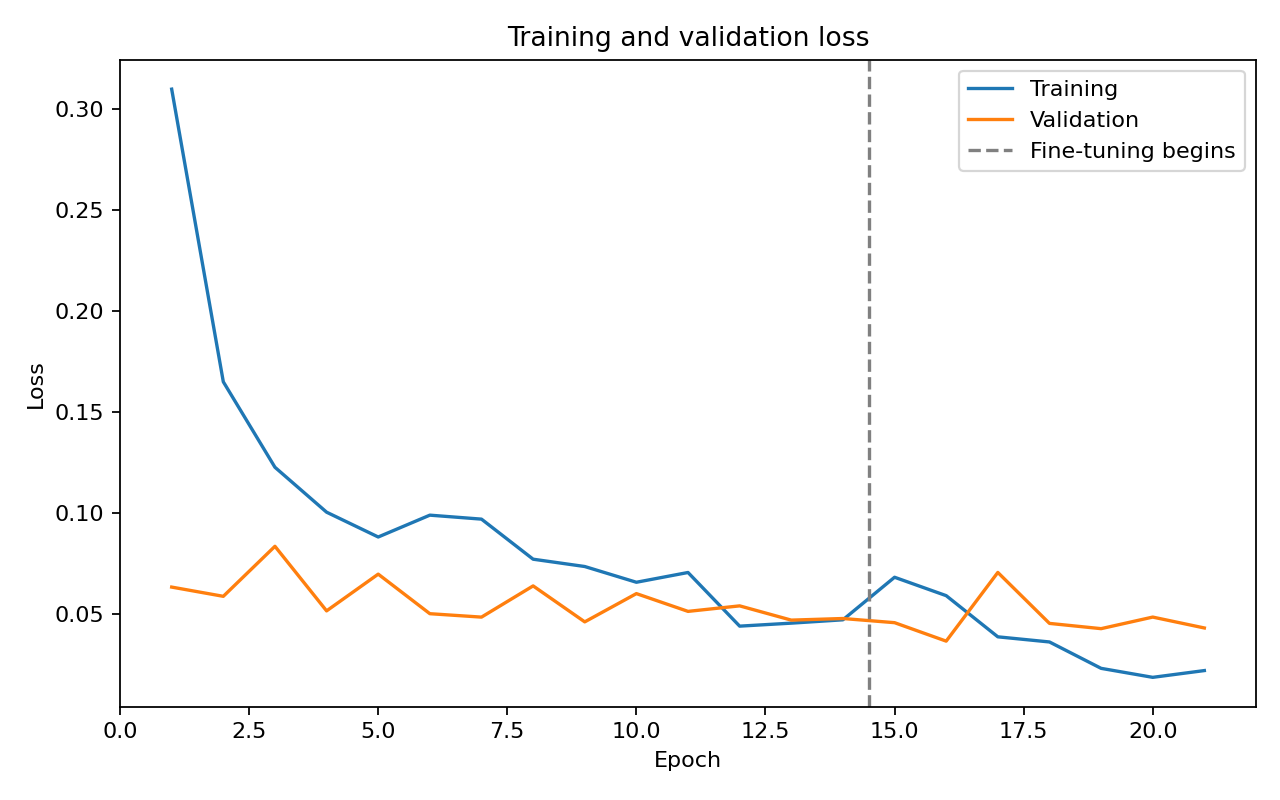

In [4]:
training_root = resolve_path(config["training_dir"], config)
for model_name in MODEL_NAMES:
    print(DISPLAY_NAMES[model_name])
    directory = training_root / model_name
    curve_paths = sorted(directory.glob("*.png")) if directory.is_dir() else []
    if not curve_paths:
        print("Not available. Training required — no measured training curves available.")
    for path in curve_paths:
        print(path.name)
        display(Image(filename=str(path), width=800))

## Inspect prediction errors

Per-image errors can reveal labeling or acquisition issues. After examining test errors, do not report further test-driven model revisions as an unbiased single held-out experiment. A new locked external test population is needed for independent confirmation.

In [5]:
for model_name in records:
    path = evaluation_root / model_name / "predictions.csv"
    if path.is_file():
        predictions = pd.read_csv(path)
        errors = predictions.loc[predictions["true_label"] != predictions["predicted_label"]]
        print(f"{DISPLAY_NAMES[model_name]}: {len(errors)} misclassified test images")
        display(errors.head(20))

Custom CNN: 189 misclassified test images


,path,true_label,true_class,predicted_label,predicted_class,probability_no_tumor,probability_tumor
1,data/test/no_tumor/notumor__Te-no_101__11d37b7...,0,no_tumor,1,tumor,0.228319,0.771681
8,data/test/no_tumor/notumor__Te-no_108__c9a25aa...,0,no_tumor,1,tumor,0.065414,0.934586
16,data/test/no_tumor/notumor__Te-no_115__13ab175...,0,no_tumor,1,tumor,0.356597,0.643403
19,data/test/no_tumor/notumor__Te-no_118__afe63d0...,0,no_tumor,1,tumor,0.066555,0.933445
23,data/test/no_tumor/notumor__Te-no_121__0ac0068...,0,no_tumor,1,tumor,0.246933,0.753067
30,data/test/no_tumor/notumor__Te-no_128__a4f7ffa...,0,no_tumor,1,tumor,0.068571,0.931429
36,data/test/no_tumor/notumor__Te-no_133__22db103...,0,no_tumor,1,tumor,0.046477,0.953523
39,data/test/no_tumor/notumor__Te-no_136__7bbdbbe...,0,no_tumor,1,tumor,0.362496,0.637504
53,data/test/no_tumor/notumor__Te-no_149__105b873...,0,no_tumor,1,tumor,0.249091,0.750909
60,data/test/no_tumor/notumor__Te-no_155__c4f0a10...,0,no_tumor,1,tumor,0.050633,0.949367


EfficientNetB0: 98 misclassified test images


,path,true_label,true_class,predicted_label,predicted_class,probability_no_tumor,probability_tumor
23,data/test/no_tumor/notumor__Te-no_121__0ac0068...,0,no_tumor,1,tumor,0.221343,0.778657
55,data/test/no_tumor/notumor__Te-no_150__82a1690...,0,no_tumor,1,tumor,0.006120,0.993880
73,data/test/no_tumor/notumor__Te-no_167__3a4344d...,0,no_tumor,1,tumor,0.001877,0.998123
374,data/test/no_tumor/notumor__Te-no_77__3897062a...,0,no_tumor,1,tumor,0.157718,0.842282
402,data/test/tumor/glioma__Te-gl_102__4813552c8ef...,1,tumor,0,no_tumor,0.518921,0.481079
406,data/test/tumor/glioma__Te-gl_106__d1edf0a4de1...,1,tumor,0,no_tumor,0.572745,0.427255
409,data/test/tumor/glioma__Te-gl_109__166d8d50958...,1,tumor,0,no_tumor,0.521541,0.478459
416,data/test/tumor/glioma__Te-gl_115__5ed1667becd...,1,tumor,0,no_tumor,0.956943,0.043057
431,data/test/tumor/glioma__Te-gl_129__917cadd5aad...,1,tumor,0,no_tumor,0.972947,0.027053
436,data/test/tumor/glioma__Te-gl_133__850000e1a14...,1,tumor,0,no_tumor,0.916796,0.083204


MobileNetV2: 105 misclassified test images


,path,true_label,true_class,predicted_label,predicted_class,probability_no_tumor,probability_tumor
23,data/test/no_tumor/notumor__Te-no_121__0ac0068...,0,no_tumor,1,tumor,0.404534,0.595466
55,data/test/no_tumor/notumor__Te-no_150__82a1690...,0,no_tumor,1,tumor,0.044015,0.955985
73,data/test/no_tumor/notumor__Te-no_167__3a4344d...,0,no_tumor,1,tumor,0.225612,0.774388
82,data/test/no_tumor/notumor__Te-no_175__28dd840...,0,no_tumor,1,tumor,0.253510,0.746490
103,data/test/no_tumor/notumor__Te-no_194__eaf5b32...,0,no_tumor,1,tumor,0.489687,0.510313
133,data/test/no_tumor/notumor__Te-no_220__242ee12...,0,no_tumor,1,tumor,0.224426,0.775574
220,data/test/no_tumor/notumor__Te-no_29__82554248...,0,no_tumor,1,tumor,0.020087,0.979913
279,data/test/no_tumor/notumor__Te-no_352__6f6b4e9...,0,no_tumor,1,tumor,0.017735,0.982265
320,data/test/no_tumor/notumor__Te-no_38__80baec6e...,0,no_tumor,1,tumor,0.140896,0.859104
374,data/test/no_tumor/notumor__Te-no_77__3897062a...,0,no_tumor,1,tumor,0.255707,0.744293


## Reporting

Sensitivity describes missed tumor-labelled images; specificity describes false-positive behavior. Precision depends on the evaluated class prevalence. Undefined values are unavailable, not zero or perfect. Raw output probabilities are not calibrated diagnostic confidence. Grad-CAM is an interpretability aid, not evidence of medically correct tumor localization. Include source version, manifest fingerprint, exclusions, class counts, training budget, and patient-independence limitations in the report.